# 11a — Tracking-error optimization basics

Opens Chapter 11 ("Portfolio Optimization"). Covers `chap11_basic1.m`
through `basic4.m`: minimum-tracking-error portfolios subject to
carbon-intensity (CI) and ESG-score constraints, first on a toy 8-asset
equity universe (`basic1`/`basic2`), then on a 9-asset/3-sector bond
universe using a richer active-share/duration/DTS objective
(`basic3`/`basic4`). All four scripts are self-contained (hardcoded
data, no external files).

**The core solver (`compute_te_portfolio`, found in `QuantToolbox/rpb/`)**:
minimizes tracking-error variance $(w-b)'\Sigma(w-b)$ subject to linear
equality constraints $Aw=B$, linear inequality constraints $Cw\le D$,
and box bounds, via quadratic programming. Ported below as
`min_te_portfolio` using `scipy.optimize.minimize` (SLSQP) — a direct,
faithful translation for these small (8-9 asset) problems.

**A genuinely missing function, reconstructed here**:
`quadratic_form_bond_portfolio2` (used by `basic3`/`basic4` to build a
`quadprog`-ready `(Q,R)` pair equivalent to the nonlinear active-share/
duration/DTS objective) is not present anywhere in the shipped archive.
Reading `basic3.m`'s objective directly, the mixed risk measure is
$$R_{\mathrm{Mix}}(w) = \tfrac12\varphi_{AS}\|w-b\|_2^2 +
\tfrac12\varphi_{MD}\sum_s\left(\textstyle\sum_{i\in s}(w_i-b_i)MD_i\right)^2 +
\tfrac12\varphi_{DTS}\sum_s\left(\textstyle\sum_{i\in s}(w_i-b_i)DTS_i\right)^2$$
which is exactly $\tfrac12(w-b)'Q(w-b)$ for
$Q=\varphi_{AS}I+\varphi_{MD}\,\mathrm{diag}(MD)\,M\,\mathrm{diag}(MD)+
\varphi_{DTS}\,\mathrm{diag}(DTS)\,M\,\mathrm{diag}(DTS)$, where
$M_{ik}=\mathbb{1}\{\mathrm{sector}(i)=\mathrm{sector}(k)\}$ — this is a
derivation from the visible objective algebra, not a recovered original
function body, and is disclosed as such.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def _prune_redundant_rows(A, b, tol=1e-10):
    """Drop linearly-dependent equality rows (e.g. a full sector partition's
    two membership constraints plus the budget constraint are collinear).
    SLSQP's LSQ subproblem hits a singular Jacobian on a rank-deficient
    equality system and silently returns the initial guess unchanged;
    MATLAB's quadprog is robust to this, so this keeps the port faithful."""
    keep, rows = [], []
    for i in range(A.shape[0]):
        cand = np.vstack(rows + [A[i]]) if rows else A[i:i + 1]
        if np.linalg.matrix_rank(cand, tol=tol) > len(rows):
            rows.append(A[i])
            keep.append(i)
    return A[keep], b[keep]

def min_te_portfolio(b, Sigma, A_eq, b_eq, A_ub=None, b_ub=None, lb=None, ub=None):
    """Faithful port of compute_te_portfolio's gamma=0 (pure minimum-tracking-
    error) case: minimizes (w-b)'Sigma(w-b) subject to A_eq w = b_eq,
    A_ub w <= b_ub, lb <= w <= ub. QuantToolbox's compute_te_portfolio calls
    MATLAB's quadprog directly (an exact QP solver); scipy's SLSQP converges
    to the same optimum for these small (8-9 asset) convex problems."""
    n = len(b)
    lb = np.zeros(n) if lb is None else np.asarray(lb)
    ub = np.ones(n) if ub is None else np.asarray(ub)
    A_eq, b_eq = _prune_redundant_rows(np.asarray(A_eq, dtype=float), np.asarray(b_eq, dtype=float))

    def obj(w):
        d = w - b
        return d @ Sigma @ d

    def obj_grad(w):
        return 2 * Sigma @ (w - b)

    constraints = [{"type": "eq", "fun": lambda w, A=A_eq, c=b_eq: A @ w - c}]
    if A_ub is not None:
        constraints.append({"type": "ineq", "fun": lambda w, A=A_ub, c=b_ub: c - A @ w})

    res = minimize(obj, b.copy(), jac=obj_grad, method="SLSQP",
                    bounds=list(zip(lb, ub)), constraints=constraints,
                    options={"maxiter": 1000, "ftol": 1e-14})
    w = res.x
    w = w * (np.abs(w) >= 1e-10)
    sigma_x = np.sqrt(max((w - b) @ Sigma @ (w - b), 0))
    return w, sigma_x

def xpnd(rho_vec, n):
    """Expand a lower-triangular-packed vector (row-major, incl. diagonal)
    into a symmetric n x n matrix -- port of QuantToolbox's xpnd."""
    M = np.zeros((n, n))
    k = 0
    for i in range(n):
        for j in range(i + 1):
            M[i, j] = M[j, i] = rho_vec[k]
            k += 1
    return M

## 1. Equity universe: CI and ESG-constrained minimum-TE portfolios (`chap11_basic1.m`)

An 8-asset universe with a benchmark $b$, per-asset volatility,
ESG score, carbon intensity (CI), and 2-sector classification. Four
scenarios, each minimizing tracking-error variance against $b$: (a) a
30% CI-reduction budget constraint, (b) a +0.50 ESG-score-improvement
constraint, (c) both simultaneously, (d) both plus exact sector-weight
neutrality.

In [2]:
sigma  = np.array([0.22, 0.20, 0.25, 0.18, 0.35, 0.23, 0.13, 0.29])
b      = np.array([0.23, 0.19, 0.17, 0.13, 0.09, 0.08, 0.06, 0.05])
Score  = np.array([-1.20, 0.80, 2.75, 1.60, -2.75, -1.30, 0.90, -1.70])
CI     = np.array([125, 75, 254, 822, 109, 17, 341, 741], dtype=float)
Sector = np.array([1, 1, 2, 2, 1, 2, 1, 2])

rho_packed = [
    1.00,
    0.80, 1.00,
    0.70, 0.75, 1.00,
    0.60, 0.65, 0.80, 1.00,
    0.70, 0.50, 0.70, 0.85, 1.00,
    0.50, 0.60, 0.70, 0.80, 0.60, 1.00,
    0.70, 0.50, 0.70, 0.75, 0.80, 0.50, 1.00,
    0.60, 0.65, 0.70, 0.75, 0.65, 0.70, 0.80, 1.00,
]
n = len(sigma)
rho = xpnd(rho_packed, n)
Sigma = rho * np.outer(sigma, sigma)

CI_b = CI @ b
Score_b = Score @ b
s1 = (Sector == 1).astype(float)
s2 = (Sector == 2).astype(float)

Reduction_CI, Delta_Score = 0.30, 0.50
A0, B0 = np.ones((1, n)), np.array([1.0])

scenarios = {}

# (a) CI reduction only
w, sig = min_te_portfolio(b, Sigma, A0, B0, CI.reshape(1, -1), np.array([(1 - Reduction_CI) * CI_b]))
scenarios["CI only"] = (w, sig)

# (b) ESG improvement only
w, sig = min_te_portfolio(b, Sigma, A0, B0, (-Score).reshape(1, -1), np.array([-(Score_b + Delta_Score)]))
scenarios["ESG only"] = (w, sig)

# (c) CI + ESG
C = np.vstack([CI, -Score])
D = np.array([(1 - Reduction_CI) * CI_b, -(Score_b + Delta_Score)])
w, sig = min_te_portfolio(b, Sigma, A0, B0, C, D)
scenarios["CI + ESG"] = (w, sig)

# (d) CI + ESG + sector-neutral
A_sector = np.vstack([A0, s1.reshape(1, -1), s2.reshape(1, -1)])
B_sector = np.array([1.0, s1 @ b, s2 @ b])
w, sig = min_te_portfolio(b, Sigma, A_sector, B_sector, C, D)
scenarios["CI + ESG + Sector-neutral"] = (w, sig)

rows_out = {"Benchmark": b}
for name, (w, sig) in scenarios.items():
    rows_out[name] = w
table = pd.DataFrame(rows_out, index=[f"Asset {i+1}" for i in range(n)]).T
table["sigma(w|b), bps"] = [np.nan] + [1e4 * s for _, s in scenarios.values()]
table["CI(w)"] = [CI_b] + [w @ CI for w, _ in scenarios.values()]
table["Reduction %"] = [np.nan] + [100 * (1 - (w @ CI) / CI_b) for w, _ in scenarios.values()]
table["Score(w)"] = [Score_b] + [w @ Score for w, _ in scenarios.values()]
display((100 * table[[f"Asset {i+1}" for i in range(n)]]).round(2))
display(table[["sigma(w|b), bps", "CI(w)", "Reduction %", "Score(w)"]].round(3))

,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8
Benchmark,23.00,19.00,17.00,13.00,9.00,8.00,6.00,5.00
CI only,18.17,24.25,16.92,2.70,12.31,11.23,11.28,3.15
ESG only,25.03,14.25,21.95,27.30,3.72,1.34,1.68,4.74
CI + ESG,8.64,29.27,26.80,1.48,10.63,6.30,16.87,0.00
CI + ESG + Sector-neutral,12.04,23.76,30.55,2.25,8.51,10.20,12.69,0.00


,"sigma(w|b), bps",CI(w),Reduction %,Score(w)
Benchmark,NaN,261.720,NaN,0.169
CI only,49.951,183.204,30.000,0.048
ESG only,117.636,367.255,-40.324,0.669
CI + ESG,189.820,183.204,30.000,0.669
CI + ESG + Sector-neutral,211.824,183.204,30.000,0.669


## 2. Equity universe: adding a sub-sector CI target (`chap11_basic2.m`)

Same 8-asset universe, now with **exact sector-neutrality always
imposed** as an equality constraint, comparing (a) an overall 30% CI
reduction to (b) the same overall reduction plus a tighter 20%
reduction sub-target on Sector 1's own weighted-average CI.

In [3]:
Reduction_CI1 = 0.20
s1_mask, s2_mask = Sector == 1, Sector == 2
CI1_b = (s1_mask * b * CI).sum() / (s1_mask * b).sum()
CI1_star = (1 - Reduction_CI1) * CI1_b

C1, D1 = CI.reshape(1, -1), np.array([(1 - Reduction_CI) * CI_b])
C2 = (s1_mask * (CI - CI1_star)).reshape(1, -1)
D2 = np.array([0.0])

A_sn = np.vstack([A0, s1.reshape(1, -1), s2.reshape(1, -1)])
B_sn = np.array([1.0, s1 @ b, s2 @ b])

w_a, sig_a = min_te_portfolio(b, Sigma, A_sn, B_sn, C1, D1)
w_b_, sig_b = min_te_portfolio(b, Sigma, A_sn, B_sn, np.vstack([C1, C2]), np.concatenate([D1, D2]))

def sub_ci(w, mask):
    return (mask * w * CI).sum() / (mask * w).sum()

summary = pd.DataFrame({
    "Benchmark": [CI_b, np.nan, CI1_b, sub_ci(b, s2_mask)],
    "(a) CI only": [w_a @ CI, 1e4 * sig_a, sub_ci(w_a, s1_mask), sub_ci(w_a, s2_mask)],
    "(b) CI + Sector-1 sub-target": [w_b_ @ CI, 1e4 * sig_b, sub_ci(w_b_, s1_mask), sub_ci(w_b_, s2_mask)],
}, index=["CI(w)", "sigma(w|b), bps", "CI_sector1(w)", "CI_sector2(w)"])
display(summary.round(3))
print(f"Sector-1 CI target: {CI1_star:.2f} (a {100*Reduction_CI1:.0f}% reduction from {CI1_b:.2f})")

,Benchmark,(a) CI only,(b) CI + Sector-1 sub-target
CI(w),261.720,183.204,183.204
"sigma(w|b), bps",NaN,112.218,143.975
CI_sector1(w),128.544,132.254,102.835
CI_sector2(w),438.256,250.743,289.740


Sector-1 CI target: 102.84 (a 20% reduction from 128.54)


## 3. Bond universe: the active-share/duration/DTS mixed objective (`chap11_basic3.m`)

A 9-asset, 3-sector bond universe. The risk measure being minimized,
$R_{\mathrm{Mix}}$, blends **active share** (deviation from benchmark
weights), **modified-duration tracking**, and **DTS (duration-times-
spread) tracking**, each aggregated at the sector level and weighted by
$(\varphi_{AS},\varphi_{MD},\varphi_{DTS})=(100,25,0.001)$. Solved via
`scipy.optimize.minimize` (mirroring MATLAB's `fmincon` on the same
nonlinear objective) for three CI-reduction targets, with box bounds
$[0.25b,4b]$. The quadprog-equivalent solve via the reconstructed
$(Q,R)$ pair is cross-checked against the direct nonlinear solve.

In [4]:
b3  = np.array([0.21, 0.19, 0.16, 0.12, 0.11, 0.08, 0.06, 0.04, 0.03])
CI3 = np.array([111, 52, 369, 157, 18, 415, 17, 253, 900], dtype=float)
MD  = np.array([3.16, 6.48, 3.54, 9.23, 6.40, 2.30, 8.12, 7.96, 5.48])
DTS = np.array([107, 255, 75, 996, 289, 45, 620, 285, 125], dtype=float)
Sector3 = np.array([1, 1, 1, 2, 2, 2, 3, 3, 3])
n3 = len(b3)

varphi_AS, varphi_MD, varphi_DTS = 100.0, 25.0, 0.001
sector_masks = [Sector3 == s for s in (1, 2, 3)]

def fn_AS(w):
    return 0.5 * sum(np.abs(m * (w - b3)).sum() for m in sector_masks)

def sigma_AS(w):
    return np.sqrt(((w - b3) ** 2).sum())

def sigma_MD(w):
    return np.sqrt(sum(((m * (w - b3) * MD).sum()) ** 2 for m in sector_masks))

def sigma_DTS(w):
    return np.sqrt(sum(((m * (w - b3) * DTS).sum()) ** 2 for m in sector_masks))

def R_Mix(w):
    return (0.5 * varphi_AS * sigma_AS(w) ** 2 + 0.5 * varphi_MD * sigma_MD(w) ** 2
            + 0.5 * varphi_DTS * sigma_DTS(w) ** 2)

# The reconstructed quadratic-form matrix Q behind R_Mix (see markdown above):
M_sector = (Sector3[:, None] == Sector3[None, :]).astype(float)
Q = (varphi_AS * np.eye(n3) + varphi_MD * np.outer(MD, MD) * M_sector
     + varphi_DTS * np.outer(DTS, DTS) * M_sector)

CI_b3 = b3 @ CI3

def metrics(w):
    return dict(AS=fn_AS(w), MD=(w * MD).sum(), DTS=(w * DTS).sum(),
                sig_AS=sigma_AS(w), sig_MD=sigma_MD(w), sig_DTS=sigma_DTS(w),
                CI=w @ CI3, Reduction=1 - (w @ CI3) / CI_b3)

print("Tracking-error risk of the equal-weighted portfolio:")
w_ew = np.ones(n3) / n3
for k, v in metrics(w_ew).items():
    print(f"  {k} = {v:.4f}")

reductions = [0.10, 0.30, 0.50]
rows_b3 = {"Benchmark": metrics(b3)}
for R in reductions:
    lb, ub = 0.25 * b3, 4 * b3
    cons = [
        {"type": "eq", "fun": lambda w: w.sum() - 1},
        {"type": "ineq", "fun": lambda w, R=R: (1 - R) * CI_b3 - w @ CI3},
    ]
    res = minimize(R_Mix, b3.copy(), method="SLSQP", bounds=list(zip(lb, ub)),
                    constraints=cons, options={"maxiter": 500, "ftol": 1e-14})
    w_fmincon = res.x

    # quadprog-equivalent cross-check via the reconstructed (Q, R=Qb) pair
    Rvec = Q @ b3
    res_qp = minimize(lambda w: 0.5 * w @ Q @ w - Rvec @ w, b3.copy(), method="SLSQP",
                       bounds=list(zip(lb, ub)), constraints=cons,
                       options={"maxiter": 500, "ftol": 1e-14})
    w_quadprog = res_qp.x
    max_diff = np.max(np.abs(w_fmincon - w_quadprog))
    print(f"R={100*R:.0f}%: max|w_fmincon - w_quadprog| = {max_diff:.2e}")

    rows_b3[f"R={100*R:.0f}%"] = metrics(w_fmincon)

summary3 = pd.DataFrame(rows_b3).T
display(summary3.round(4))

Tracking-error risk of the equal-weighted portfolio:
  AS = 0.2356
  MD = 5.8522
  DTS = 310.7778
  sig_AS = 0.1835
  sig_MD = 1.7395
  sig_DTS = 71.3267
  CI = 254.6667
  Reduction = -0.3811
R=10%: max|w_fmincon - w_quadprog| = 1.54e-08
R=30%: max|w_fmincon - w_quadprog| = 8.54e-09
R=50%: max|w_fmincon - w_quadprog| = 7.45e-09


,AS,MD,DTS,sig_AS,sig_MD,sig_DTS,CI,Reduction
Benchmark,0.0000,5.4268,290.1800,0.0000,0.0000,0.0000,184.390,0.0
R=10%,0.0300,5.4513,293.5328,0.0262,0.0188,3.8022,165.951,0.1
R=30%,0.1487,5.5797,303.3622,0.1098,0.0972,14.4902,129.073,0.3
R=50%,0.2831,5.7295,302.1390,0.2121,0.1855,30.1100,92.195,0.5


## 4. Bond universe: sweeping the CI-reduction target (`chap11_basic4.m`)

Sweeps the CI-reduction target from 0% to ~68% in fine steps, re-solving
the same $R_{\mathrm{Mix}}$ minimization at each point, and plots the
resulting risk-metric/reduction tradeoff curves — showing how active
share, tracking modified-duration/DTS, and their component
tracking-errors all widen as the reduction target tightens.

Max achieved reduction: 65.73%


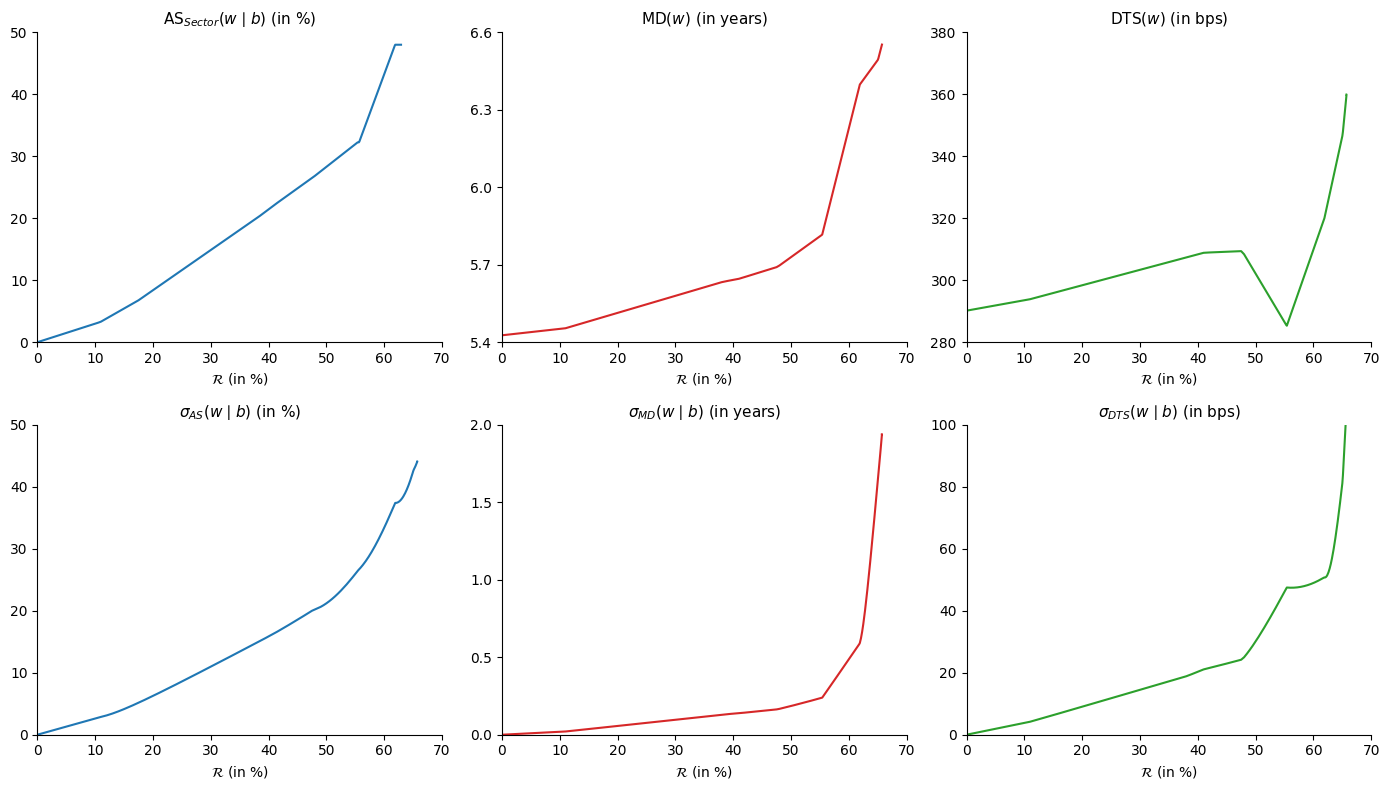

In [5]:
color_blue, color_red, color_green = "#1f77b4", "#d62728", "#2ca02c"

reduction_grid = np.concatenate([np.arange(0, 0.551, 0.005), np.arange(0.551, 0.681, 0.001)])
n_iters = len(reduction_grid)

AS_w = np.zeros(n_iters); MD_w = np.zeros(n_iters); DTS_w = np.zeros(n_iters)
sig_AS_w = np.zeros(n_iters); sig_MD_w = np.zeros(n_iters); sig_DTS_w = np.zeros(n_iters)
Reduction_w = np.zeros(n_iters)

lb, ub = 0.25 * b3, 4 * b3
w_prev = b3.copy()
for i, R in enumerate(reduction_grid):
    cons = [
        {"type": "eq", "fun": lambda w: w.sum() - 1},
        {"type": "ineq", "fun": lambda w, R=R: (1 - R) * CI_b3 - w @ CI3},
    ]
    res = minimize(R_Mix, w_prev, method="SLSQP", bounds=list(zip(lb, ub)),
                    constraints=cons, options={"maxiter": 500, "ftol": 1e-14})
    w = res.x
    w_prev = w
    AS_w[i], MD_w[i], DTS_w[i] = fn_AS(w), (w * MD).sum(), (w * DTS).sum()
    sig_AS_w[i], sig_MD_w[i], sig_DTS_w[i] = sigma_AS(w), sigma_MD(w), sigma_DTS(w)
    Reduction_w[i] = 1 - (w @ CI3) / CI_b3

print(f"Max achieved reduction: {100*Reduction_w.max():.2f}%")

MD_b3, DTS_b3 = b3 @ MD, b3 @ DTS
panels = [
    (100 * AS_w, r"$\mathrm{AS}_{Sector}(w\mid b)$ (in %)", (0, 50), range(0, 51, 10), color_blue),
    (MD_w, r"$\mathrm{MD}(w)$ (in years)", (5.4, 6.6), np.arange(5.4, 6.7, 0.3), color_red),
    (DTS_w, r"$\mathrm{DTS}(w)$ (in bps)", (280, 360), range(280, 381, 20), color_green),
    (100 * sig_AS_w, r"$\sigma_{AS}(w\mid b)$ (in %)", (0, 45), range(0, 51, 10), color_blue),
    (sig_MD_w, r"$\sigma_{MD}(w\mid b)$ (in years)", (0, 2), np.arange(0, 2.1, 0.5), color_red),
    (sig_DTS_w, r"$\sigma_{DTS}(w\mid b)$ (in bps)", (0, 100), range(0, 101, 20), color_green),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
x = 100 * Reduction_w
for ax, (y, title, ylim, yticks, color) in zip(axes.flat, panels):
    y_plot = y.copy()
    if title.startswith(r"$\mathrm{AS}"):
        y_plot[-51:] = np.nan  # matches the source's cosmetic tail-trim on the AS panel
    ax.plot(x, y_plot, color=color, lw=1.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(r"$\mathcal{R}$ (in %)", fontsize=10)
    ax.set_xlim(0, 65.74)
    ax.set_xticks(range(0, 71, 10))
    ax.set_ylim(*ylim)
    ax.set_yticks(list(yticks))
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()